# **Instagram Reels Virality Prediction — Logistic Regression**


 1. Library Import

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


2. Random Seed

In [ ]:
RANDOM_STATE = 42

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



3. Load Dataset


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datascience/instagram_data.csv')

 4. Basic Data Check

In [ ]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows")
display(df.head())

print("\nData Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

Dataset Shape: (100000, 26)

First 5 Rows


,reel_id,creator_id,creator_followers,posting_time,reel_length_sec,hook_strength_score,caption_length,hashtags_count,trending_audio,audio_popularity_score,...,likes,comments,shares,saves,engagement_rate,impressions,reach,non_follower_reach_ratio,explore_page_boost,virality_score
0,c437715e-d1e4-4f40-8548-8718243c6516,70c2ca5a-9d3a-4ba0-9aed-62cdbbc1663f,4208388,3,31,0.451657,0,20,True,0.399659,...,779301,30002,16741,21305,0.884296,75968410,39007279,0.960121,False,82.843160
1,9097bb11-0e03-4360-a239-6613ed2025df,b6bb4240-6341-47ce-bdd4-86fcba18d9ad,4096880,4,38,0.988437,205,2,False,0.294848,...,482481,49717,10095,19802,0.609125,90722120,84132612,0.909716,False,60.256519
2,a8e09994-3314-400b-9f3a-683b494f1070,7902b14d-cb95-4673-8ef1-482ff5151801,2624351,0,13,0.019949,205,6,True,0.697575,...,925249,12046,13883,13444,0.057583,75215994,82019789,0.101694,True,0.483295
3,afafb1c3-90c4-4918-8910-3a2338a812c5,3878d999-6087-4a40-a59e-45abe8978736,437778,23,15,0.564485,292,1,False,0.271352,...,633556,37062,5290,245,0.927607,32759775,89513213,0.900505,False,21.686033
4,dcb1e68c-79ba-4808-bf74-d102fa68a526,4077faf8-bc0c-42df-b060-f90d074e8e01,4388903,3,30,0.556782,215,27,False,0.757624,...,55799,16634,5733,19235,0.723132,12315042,25073380,0.589176,True,46.046599



Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   reel_id                   100000 non-null  object 
 1   creator_id                100000 non-null  object 
 2   creator_followers         100000 non-null  int64  
 3   posting_time              100000 non-null  int64  
 4   reel_length_sec           100000 non-null  int64  
 5   hook_strength_score       100000 non-null  float64
 6   caption_length            100000 non-null  int64  
 7   hashtags_count            100000 non-null  int64  
 8   trending_audio            100000 non-null  bool   
 9   audio_popularity_score    100000 non-null  float64
 10  video_quality_score       100000 non-null  float64
 11  editing_quality_score     100000 non-null  float64
 12  avg_watch_time_sec        100000 non-null  float64
 13  retention_rate            100000 n

5. Remove Leakage Features

In [ ]:
drop_columns = [
    'likes',
    'comments',
    'shares',
    'saves',
    'impressions',
    'reach',
    'engagement_rate',
    'reel_id',
    'creator_id'
]

# 존재하는 컬럼만 제거
df = df.drop(
    columns=[col for col in drop_columns if col in df.columns]
)

print("\nRemoved Leakage / ID Columns")


Removed Leakage / ID Columns



6. Create Target Label

### Supervised Learning Setup


In [ ]:
# Viral Score >= 80 -> Viral(1)
# Viral Score < 80 -> Non-Viral(0)
df['viral_label'] = (df['virality_score'] >= 80).astype(int)

# 기존 virality_score 제거
df = df.drop(columns=['virality_score'])

print("\nTarget Label Created")


Target Label Created


7. Target Distribution


Target Distribution
viral_label
0    79764
1    20236
Name: count, dtype: int64

Target Distribution Ratio
viral_label
0    0.79764
1    0.20236
Name: proportion, dtype: float64


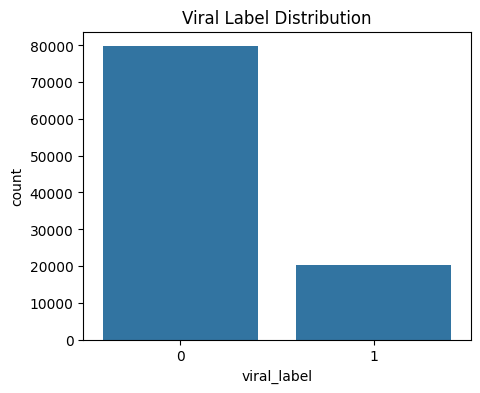

In [ ]:
print("\nTarget Distribution")
print(df['viral_label'].value_counts())

print("\nTarget Distribution Ratio")
print(df['viral_label'].value_counts(normalize=True))

# 시각화
plt.figure(figsize=(5,4))
sns.countplot(x='viral_label', data=df)
plt.title('Viral Label Distribution')
plt.show()

8. Separate X and y

In [ ]:
X = df.drop(columns=['viral_label'])
y = df['viral_label']

9. Identify Numeric / Categorical Columns

In [ ]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print("\nNumeric Columns")
print(list(numeric_cols))

print("\nCategorical Columns")
print(list(categorical_cols))



Numeric Columns
['creator_followers', 'posting_time', 'reel_length_sec', 'hook_strength_score', 'caption_length', 'hashtags_count', 'audio_popularity_score', 'video_quality_score', 'editing_quality_score', 'avg_watch_time_sec', 'retention_rate', 'completion_rate', 'rewatch_rate', 'non_follower_reach_ratio']

Categorical Columns
[]


 10. Missing Value Handling

### Data Cleaning (Missing Data Handling)


In [ ]:
# Numeric -> Median Imputation
num_imputer = SimpleImputer(
    strategy='median'
)

X[numeric_cols] = num_imputer.fit_transform(
    X[numeric_cols]
)

# Categorical -> Most Frequent Imputation
if len(categorical_cols) > 0:

    cat_imputer = SimpleImputer(
        strategy='most_frequent'
    )

    X[categorical_cols] = cat_imputer.fit_transform(
        X[categorical_cols]
    )

else:
    print("\nNo categorical columns found.")

print("\nMissing Value Handling Complete")


No categorical columns found.

Missing Value Handling Complete



11. One-Hot Encoding

In [ ]:
if len(categorical_cols) > 0:

    X = pd.get_dummies(
        X,
        columns=categorical_cols,
        drop_first=True
    )

else:
    print("\nNo categorical columns to encode.")

print("\nEncoding Complete")
print("Encoded Data Shape:", X.shape)


No categorical columns to encode.

Encoding Complete
Encoded Data Shape: (100000, 16)


12. Correlation Heatmap

13. Numeric Feature Distribution

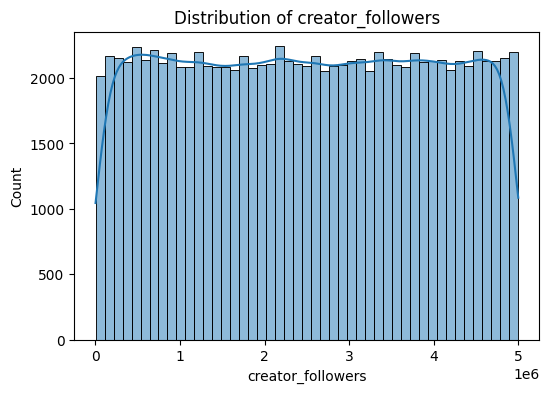

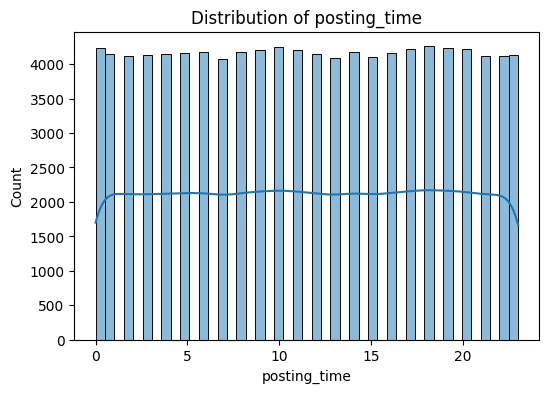

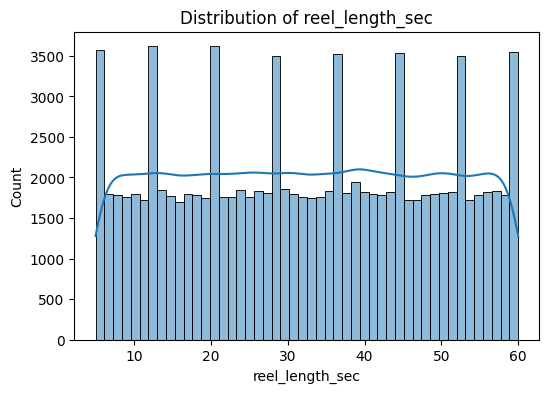

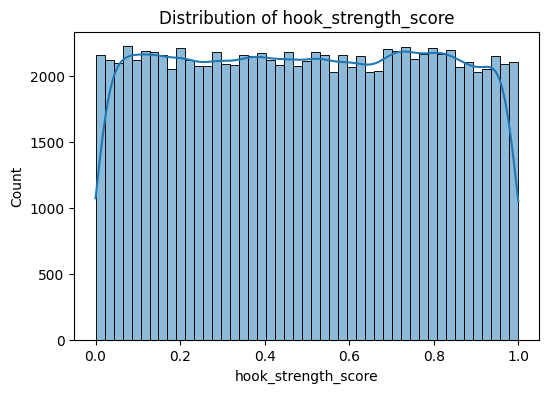

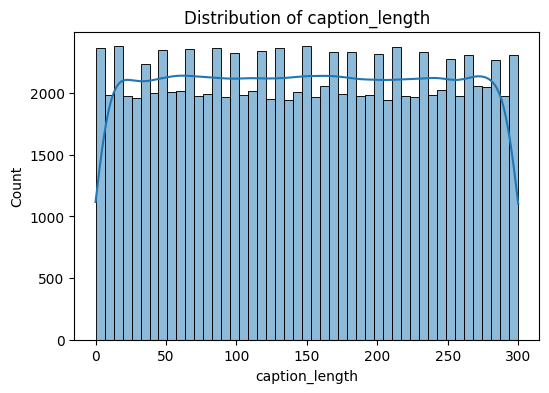

In [ ]:
for col in numeric_cols[:5]:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f'Distribution of {col}')
    plt.show()

14. Boxplot for Outlier Check

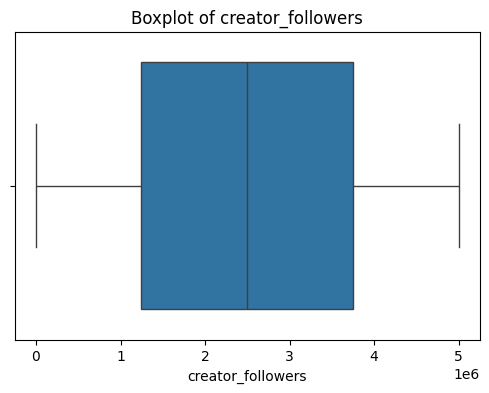

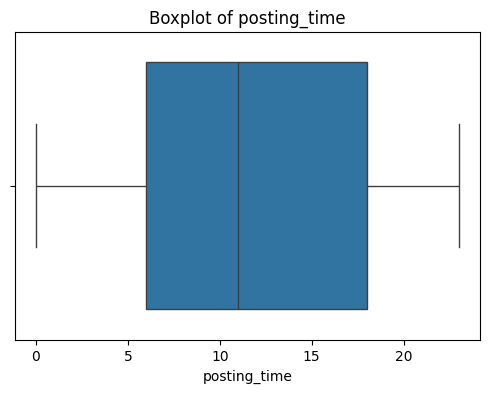

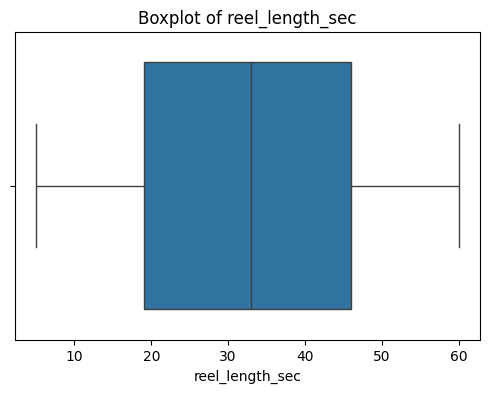

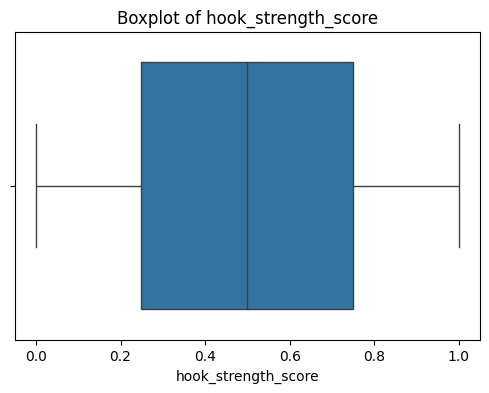

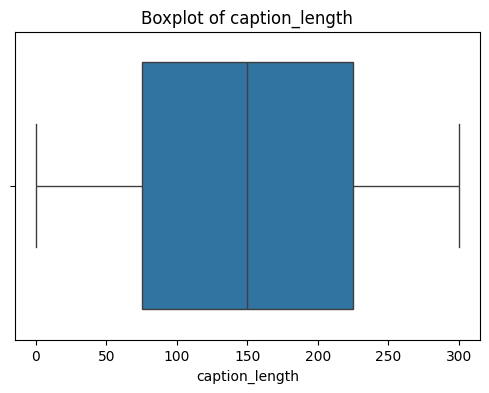

In [ ]:
for col in numeric_cols[:5]:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')
    plt.show()

15. Train/Test Split

### Sampling (Stratified Sampling)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\nTrain/Test Split Complete")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Train/Test Split Complete
X_train shape: (80000, 16)
X_test shape: (20000, 16)


16. Final Check

In [ ]:
print("\nTrain Label Distribution")
print(y_train.value_counts(normalize=True))

print("\nTest Label Distribution")
print(y_test.value_counts(normalize=True))

print("\nCommon Preprocessing & EDA Complete!")


Train Label Distribution
viral_label
0    0.797637
1    0.202363
Name: proportion, dtype: float64

Test Label Distribution
viral_label
0    0.79765
1    0.20235
Name: proportion, dtype: float64

Common Preprocessing & EDA Complete!


# **4단계 Modeling — Logistic Regression**

## 17. Library Import (Modeling)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc, log_loss
)

import warnings
warnings.filterwarnings('ignore')


## 18. Boolean Column Handling

###  Quantitative Data


In [ ]:
bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()
print("Boolean Columns:", bool_cols)

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

print("\nTrain dtypes (요약):")
print(X_train.dtypes.value_counts())


Boolean Columns: ['trending_audio', 'explore_page_boost']

Train dtypes (요약):
float64    14
int64       2
Name: count, dtype: int64


## 19. Feature Scaling — Z-score Normalization



In [ ]:
scaler = StandardScaler()   # Z-score normalization (Lecture 5)

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Z-score Normalization 적용 완료")
print("(train) mean ≈ 0, std ≈ 1 확인 — 일부 컬럼")
print(X_train_scaled.describe().loc[['mean','std']].T.head())


Z-score Normalization 적용 완료
(train) mean ≈ 0, std ≈ 1 확인 — 일부 컬럼
                             mean       std
creator_followers   -7.469581e-17  1.000006
posting_time        -8.775203e-17  1.000006
reel_length_sec     -6.625811e-17  1.000006
hook_strength_score  3.242739e-16  1.000006
caption_length       6.625811e-17  1.000006


## 20. Pearson Correlation 분석

=== Pearson Correlation with viral_label (Top 10 |corr|) ===
video_quality_score         0.0048
retention_rate              0.0044
trending_audio              0.0038
caption_length              0.0033
posting_time               -0.0031
editing_quality_score      -0.0031
completion_rate            -0.0023
non_follower_reach_ratio    0.0023
explore_page_boost          0.0021
audio_popularity_score     -0.0018
Name: viral_label, dtype: float64


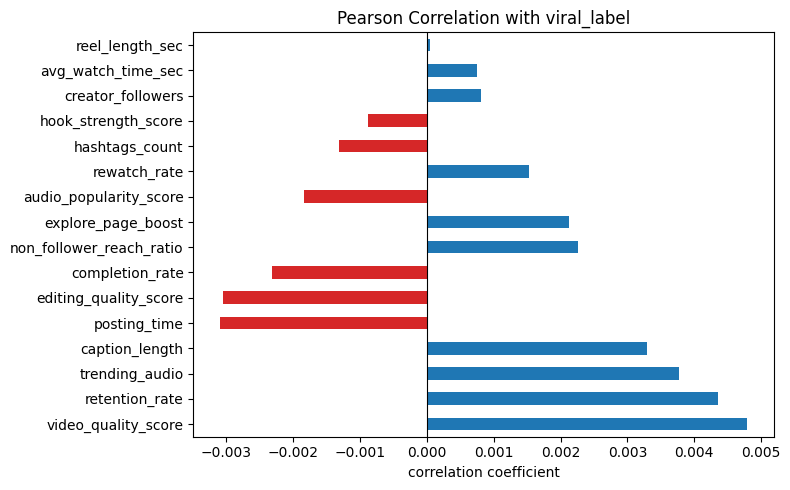

In [ ]:
# 라벨과의 Pearson Correlation
corr_with_label = X_train_scaled.copy()
corr_with_label['viral_label'] = y_train.values
pearson_corr = corr_with_label.corr(method='pearson')['viral_label'].drop('viral_label')
pearson_corr = pearson_corr.sort_values(key=lambda s: s.abs(), ascending=False)

print("=== Pearson Correlation with viral_label (Top 10 |corr|) ===")
print(pearson_corr.head(10).round(4))

plt.figure(figsize=(8,5))
pearson_corr.plot(kind='barh', color=['#1f77b4' if v>=0 else '#d62728' for v in pearson_corr])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Pearson Correlation with viral_label')
plt.xlabel('correlation coefficient')
plt.tight_layout()
plt.show()


## 21. Baseline Logistic Regression



In [ ]:
baseline_lr = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='lbfgs'
)
baseline_lr.fit(X_train_scaled, y_train)

y_pred_base  = baseline_lr.predict(X_test_scaled)
y_proba_base = baseline_lr.predict_proba(X_test_scaled)[:, 1]

print("=== Baseline Logistic Regression ===")
print(f"Accuracy        : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision       : {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall          : {recall_score(y_test, y_pred_base):.4f}")
print(f"F1              : {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC         : {roc_auc_score(y_test, y_proba_base):.4f}")
print(f"Cross-Entropy   : {log_loss(y_test, y_proba_base):.4f}")


=== Baseline Logistic Regression ===
Accuracy        : 0.7976
Precision       : 0.0000
Recall          : 0.0000
F1              : 0.0000
ROC-AUC         : 0.5000
Cross-Entropy   : 0.5037


## 22. Class Imbalance 대응 — `class_weight='balanced'`

In [ ]:
balanced_lr = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced'
)
balanced_lr.fit(X_train_scaled, y_train)

y_pred_bal  = balanced_lr.predict(X_test_scaled)
y_proba_bal = balanced_lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression with class_weight='balanced' ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_bal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_bal):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_bal):.4f}")
print(f"F1       : {f1_score(y_test, y_pred_bal):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_bal):.4f}")


=== Logistic Regression with class_weight='balanced' ===
Accuracy : 0.5044
Precision: 0.2035
Recall   : 0.4972
F1       : 0.2887
ROC-AUC  : 0.5001


## 23. Hyperparameter Tuning — GridSearchCV

In [ ]:
dparam_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=LogisticRegression(
        solver='liblinear',
        random_state=RANDOM_STATE,
        max_iter=1000
    ),
    param_grid=dparam_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

print("\nBest Params :", grid.best_params_)
print(f"Best CV F1  : {grid.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Params : {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1'}
Best CV F1  : 0.2861


# **5단계 Evaluation**

## 24. Best Model 종합 평가

In [ ]:
best_lr = grid.best_estimator_

y_pred_best  = best_lr.predict(X_test_scaled)
y_proba_best = best_lr.predict_proba(X_test_scaled)[:, 1]

print("=== Best Tuned Logistic Regression ===")
print(f"Accuracy       : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision      : {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall         : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1             : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC        : {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"Cross-Entropy  : {log_loss(y_test, y_proba_best):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_best, target_names=['Non-Viral(0)', 'Viral(1)']))

# 모델별 종합 비교
summary = pd.DataFrame({
    'Baseline': [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base),
        roc_auc_score(y_test, y_proba_base),
        log_loss(y_test, y_proba_base),
    ],
    'Balanced': [
        accuracy_score(y_test, y_pred_bal),
        precision_score(y_test, y_pred_bal),
        recall_score(y_test, y_pred_bal),
        f1_score(y_test, y_pred_bal),
        roc_auc_score(y_test, y_proba_bal),
        log_loss(y_test, y_proba_bal),
    ],
    'Tuned(Best)': [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best),
        roc_auc_score(y_test, y_proba_best),
        log_loss(y_test, y_proba_best),
    ]
}, index=['Accuracy','Precision','Recall','F1','ROC-AUC','Cross-Entropy'])

print("\n=== Baseline vs Balanced vs Tuned ===")
print(summary.round(4))


=== Best Tuned Logistic Regression ===
Accuracy       : 0.5026
Precision      : 0.2037
Recall         : 0.5011
F1             : 0.2896
ROC-AUC        : 0.4997
Cross-Entropy  : 0.6932

--- Classification Report ---
              precision    recall  f1-score   support

Non-Viral(0)       0.80      0.50      0.62     15953
    Viral(1)       0.20      0.50      0.29      4047

    accuracy                           0.50     20000
   macro avg       0.50      0.50      0.45     20000
weighted avg       0.68      0.50      0.55     20000


=== Baseline vs Balanced vs Tuned ===
               Baseline  Balanced  Tuned(Best)
Accuracy         0.7976    0.5044       0.5026
Precision        0.0000    0.2035       0.2037
Recall           0.0000    0.4972       0.5011
F1               0.0000    0.2887       0.2896
ROC-AUC          0.5000    0.5001       0.4997
Cross-Entropy    0.5037    0.6931       0.6932


## 25. Confusion Matrix
분류 결과의 TP/FP/TN/FN 구조.

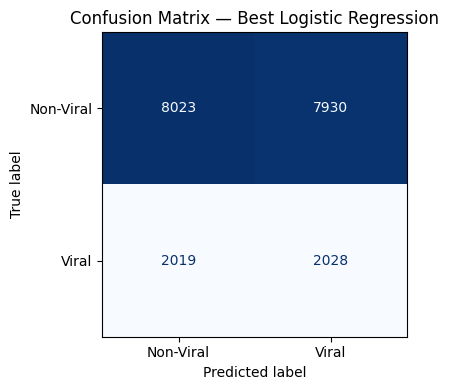

TN=8023, FP=7930, FN=2019, TP=2028
Specificity (TN/(TN+FP)) : 0.5029
Sensitivity (Recall)     : 0.5011


In [ ]:
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Viral','Viral'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title('Confusion Matrix — Best Logistic Regression')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Specificity (TN/(TN+FP)) : {tn/(tn+fp):.4f}")
print(f"Sensitivity (Recall)     : {tp/(tp+fn):.4f}")


## 26. ROC Curve


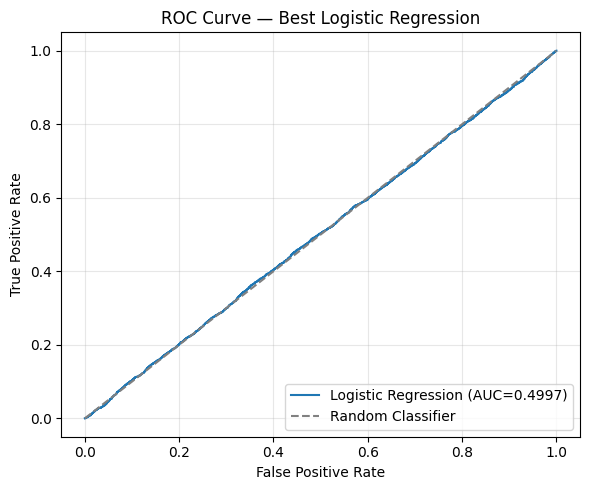

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC={roc_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Best Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 27. 학습된 가중치(Weight) 해석


- $w_i > 0$ → 해당 feature가 커질수록 Viral 확률 증가
- $w_i < 0$ → 해당 feature가 커질수록 Viral 확률 감소


=== Top 15 Features by |weight| ===
                 feature  weight (w)      |w|
     video_quality_score    0.011549 0.011549
          retention_rate    0.010261 0.010261
          trending_audio    0.008866 0.008866
          caption_length    0.007659 0.007659
            posting_time   -0.007041 0.007041
   editing_quality_score   -0.006999 0.006999
         completion_rate   -0.005314 0.005314
non_follower_reach_ratio    0.005213 0.005213
      explore_page_boost    0.004950 0.004950
  audio_popularity_score   -0.003872 0.003872
            rewatch_rate    0.003086 0.003086
          hashtags_count   -0.002735 0.002735
     hook_strength_score   -0.001513 0.001513
       creator_followers    0.001402 0.001402
      avg_watch_time_sec    0.001393 0.001393


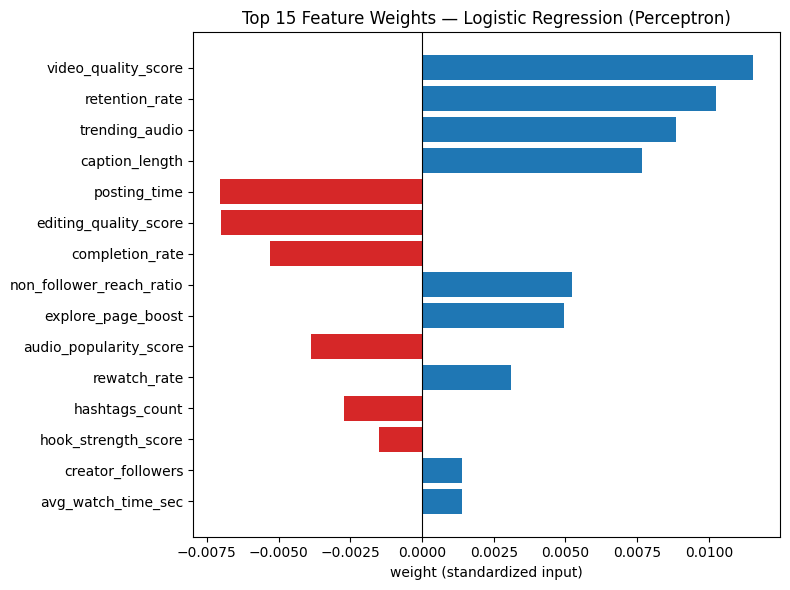


Bias (b) = 0.0000


In [ ]:
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'weight (w)': best_lr.coef_[0]
})
coef_df['|w|'] = coef_df['weight (w)'].abs()
coef_df = coef_df.sort_values('|w|', ascending=False).reset_index(drop=True)

print("=== Top 15 Features by |weight| ===")
print(coef_df.head(15).to_string(index=False))

top_n = min(15, len(coef_df))
top = coef_df.head(top_n).iloc[::-1]
colors = ['#d62728' if c < 0 else '#1f77b4' for c in top['weight (w)']]

plt.figure(figsize=(8, 6))
plt.barh(top['feature'], top['weight (w)'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('weight (standardized input)')
plt.title(f'Top {top_n} Feature Weights — Logistic Regression (Perceptron)')
plt.tight_layout()
plt.show()

print(f"\nBias (b) = {best_lr.intercept_[0]:.4f}")


## 28. 임계값(Threshold) 비교 실험 — 80점 vs 60점

In [ ]:
def run_lr_experiment(df_full, threshold, random_state=RANDOM_STATE):
    """공통 전처리 + LR 학습/평가를 임계값별로 재실행."""
    data = df_full.copy()

    # Data Reduction (Lecture 5)
    drop_cols = ['likes','comments','shares','saves','impressions',
                 'reach','engagement_rate','reel_id','creator_id']
    data = data.drop(columns=[c for c in drop_cols if c in data.columns])

    # Label generation (Lecture 6 - supervised setup)
    data['viral_label'] = (data['virality_score'] >= threshold).astype(int)
    data = data.drop(columns=['virality_score'])

    X_ = data.drop(columns=['viral_label'])
    y_ = data['viral_label']

    # Boolean -> int
    bcols = X_.select_dtypes(include=['bool']).columns.tolist()
    X_[bcols] = X_[bcols].astype(int)

    # Stratified Split (Lecture 5)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_, y_, test_size=0.2, stratify=y_, random_state=random_state
    )

    # Z-score Normalization (Lecture 5)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    # Logistic Regression (Lecture 7)
    lr = LogisticRegression(
        **{k: v for k, v in grid.best_params_.items()},
        solver='liblinear',
        random_state=random_state,
        max_iter=1000
    )
    lr.fit(X_tr_s, y_tr)

    y_p   = lr.predict(X_te_s)
    y_prb = lr.predict_proba(X_te_s)[:, 1]

    return {
        'threshold': threshold,
        'viral_ratio(train)': round(y_tr.mean(), 4),
        'Accuracy': round(accuracy_score(y_te, y_p), 4),
        'Precision': round(precision_score(y_te, y_p), 4),
        'Recall': round(recall_score(y_te, y_p), 4),
        'F1': round(f1_score(y_te, y_p), 4),
        'ROC-AUC': round(roc_auc_score(y_te, y_prb), 4),
        'CrossEntropy': round(log_loss(y_te, y_prb), 4),
    }

df_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datascience/instagram_data.csv')

results = []
for th in [80, 60]:
    r = run_lr_experiment(df_raw, th)
    results.append(r)
    print(f"[Threshold {th}] {r}")

threshold_df = pd.DataFrame(results).set_index('threshold')
print("\n=== Threshold Comparison ===")
print(threshold_df)


[Threshold 80] {'threshold': 80, 'viral_ratio(train)': np.float64(0.2024), 'Accuracy': 0.5026, 'Precision': 0.2037, 'Recall': 0.5011, 'F1': 0.2896, 'ROC-AUC': np.float64(0.4997), 'CrossEntropy': 0.6932}
[Threshold 60] {'threshold': 60, 'viral_ratio(train)': np.float64(0.4008), 'Accuracy': 0.4997, 'Precision': 0.4003, 'Recall': 0.4985, 'F1': 0.444, 'ROC-AUC': np.float64(0.5001), 'CrossEntropy': 0.6932}

=== Threshold Comparison ===
           viral_ratio(train)  Accuracy  Precision  Recall      F1  ROC-AUC  \
threshold                                                                     
80                     0.2024    0.5026     0.2037  0.5011  0.2896   0.4997   
60                     0.4008    0.4997     0.4003  0.4985  0.4440   0.5001   

           CrossEntropy  
threshold                
80               0.6932  
60               0.6932  
